In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mcu_reference_data import MCU_DATA

df = pd.DataFrame(MCU_DATA)
df["wlcsp_dims_mm"] = df["wlcsp_size_mm"].apply(
    lambda t: f"{t[0]}x{t[1]}" if isinstance(t, tuple) else None
)

table_cols = ["manufacturer", "mcu_name", "usage_class", "core",
              "wlcsp_dims_mm", "wlcsp_area_mm2", "process_node_nm",
              "run_uA_per_MHz", "sleep_current_uA"]
pd.set_option("display.max_rows", None)
pd.set_option("display.width", 200)
df[table_cols]


,manufacturer,mcu_name,usage_class,core,wlcsp_dims_mm,wlcsp_area_mm2,process_node_nm,run_uA_per_MHz,sleep_current_uA
0,STMicroelectronics,STM32L011E4,ULP,Cortex-M0+,2.133x2.07,4.42,90.0,130.00,0.230
1,STMicroelectronics,STM32L031x4/x6,ULP,Cortex-M0+,None,NaN,90.0,76.00,0.230
2,STMicroelectronics,STM32L051x6/x8,ULP,Cortex-M0+,2.61x2.88,7.52,90.0,140.00,0.280
3,STMicroelectronics,STM32L451xx,ULP,Cortex-M4F,3.36x3.66,12.30,90.0,84.00,2.050
4,STMicroelectronics,STM32C011/STM32C031 (STM32C0 series),Low-cost,Cortex-M0+,1.7x1.42,2.41,90.0,80.00,8.000
5,STMicroelectronics,STM32G0 series (Value line),Low-cost,Cortex-M0+,1.86x2.14,3.98,90.0,85.00,0.400
6,STMicroelectronics,STM32F745/F746/F756,High-performance,Cortex-M7,4.54x5.85,26.55,90.0,NaN,NaN
7,STMicroelectronics,STM32U031 (U0 series),ULP,Cortex-M0+,2.55x2.34,5.97,NaN,78.00,0.030
8,STMicroelectronics,STM32U575 (U5 series),ULP,Cortex-M33,4.2x3.95,16.59,NaN,19.50,0.210
9,Nordic Semiconductor,nRF52805,ULP,Cortex-M4,2.48x2.46,6.10,55.0,NaN,0.300


In [2]:
# ------------------------------------------------------------------
# Group Cortex core variants into 8 families for a legend that stays
# readable, and assign each family a color from the validated
# categorical palette (fixed order -> colorblind-safe adjacent pairs,
# per the dataviz skill; do not reorder or reassign ad hoc).
# ------------------------------------------------------------------
CORE_FAMILY = {
    "Cortex-M0+": "Cortex-M0+",
    "Cortex-M23": "Cortex-M23",
    "Cortex-M3 (+ LPDSP32 DSP)": "Cortex-M3",
    "Cortex-M4": "Cortex-M4",
    "Cortex-M4F": "Cortex-M4F",
    "Cortex-M33": "Cortex-M33",
    "Cortex-M33 (+ RISC-V coprocessor)": "Cortex-M33",
    "Cortex-M7": "Cortex-M7",
    "Cortex-M7 + Cortex-M4": "Cortex-M7",
    "MSP430 (non-ARM, 16-bit)": "Other / dual-core",
    "Cortex-M4F + Cortex-M0+": "Other / dual-core",
}

# Validated 8-slot categorical order (references/palette.md in the
# dataviz skill) -- worst adjacent CVD deltaE 9.1, worst adjacent
# normal-vision deltaE 19.6 on the light surface. Reused verbatim.
FAMILY_ORDER = ["Cortex-M0+", "Cortex-M4F", "Cortex-M33", "Cortex-M4",
                 "Cortex-M7", "Cortex-M3", "Cortex-M23", "Other / dual-core"]
FAMILY_COLORS = {
    "Cortex-M0+":        "#2a78d6",  # blue
    "Cortex-M4F":        "#eb6834",  # orange
    "Cortex-M33":        "#1baf7a",  # aqua
    "Cortex-M4":         "#eda100",  # yellow
    "Cortex-M7":         "#e87ba4",  # magenta
    "Cortex-M3":         "#008300",  # green
    "Cortex-M23":        "#4a3aa7",  # violet
    "Other / dual-core": "#e34948",  # red
}

df["core_family"] = df["core"].map(CORE_FAMILY)
assert df["core_family"].isna().sum() == 0, "Unmapped core string(s) found"
df["core_family"].value_counts().reindex(FAMILY_ORDER)


core_family
Cortex-M0+           18
Cortex-M4F            5
Cortex-M33            4
Cortex-M4             5
Cortex-M7             1
Cortex-M3             1
Cortex-M23            2
Other / dual-core     2
Name: count, dtype: int64

Plotting 32 of 38 entries with known WLCSP area.
Skipped (no WLCSP area found): ['STM32L031x4/x6', 'nRF52832', 'SAML10', 'SAM D5x/E5x', 'Apollo4 Blue Plus', 'EFM32WG (Wonder Gecko)']


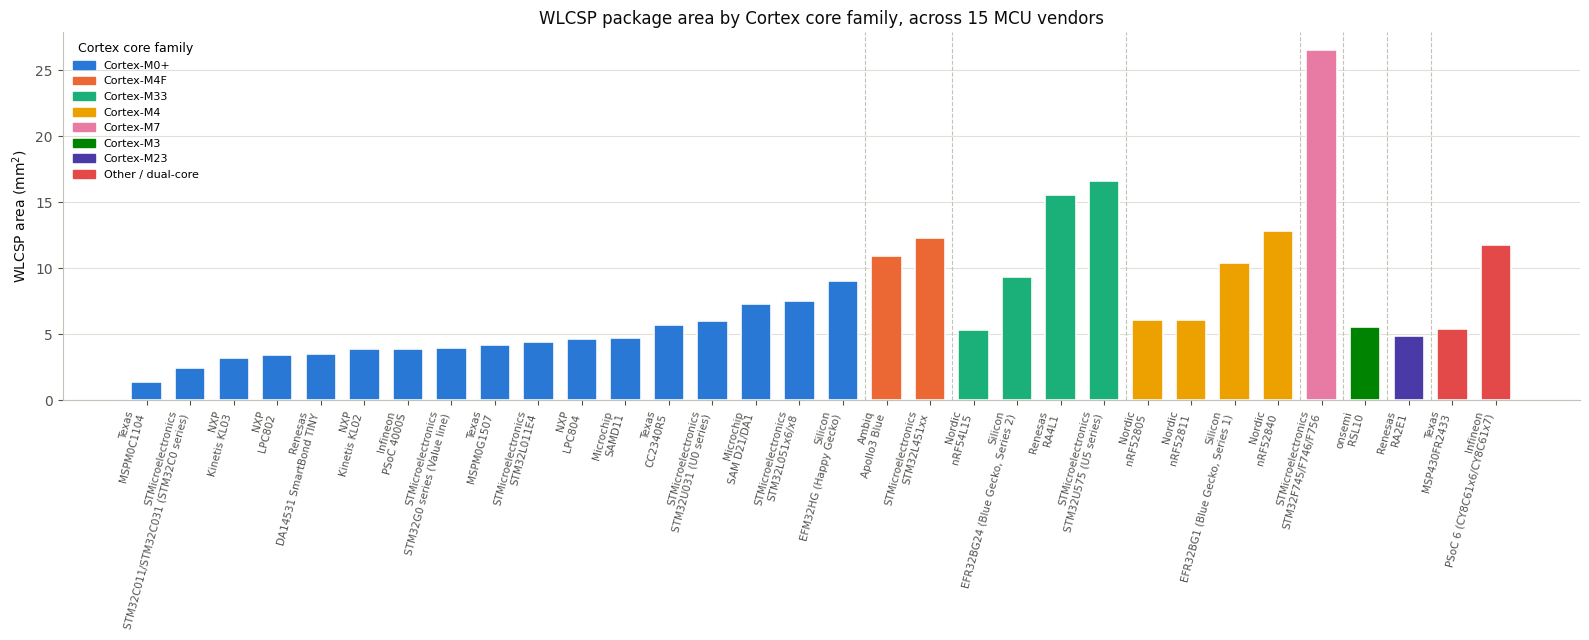

In [3]:
# ------------------------------------------------------------------
# WLCSP area (mm^2), grouped by Cortex core family.
# Entries with no known WLCSP area are skipped (listed below).
# ------------------------------------------------------------------
plot_df = df.dropna(subset=["wlcsp_area_mm2"]).copy()
skipped = df.loc[df["wlcsp_area_mm2"].isna(), "mcu_name"].tolist()
print(f"Plotting {len(plot_df)} of {len(df)} entries with known WLCSP area.")
print(f"Skipped (no WLCSP area found): {skipped}")

plot_df["family_rank"] = plot_df["core_family"].apply(FAMILY_ORDER.index)
plot_df = plot_df.sort_values(["family_rank", "wlcsp_area_mm2"])
plot_df["label"] = plot_df["manufacturer"].str.split().str[0] + "\n" + plot_df["mcu_name"]

fig, ax = plt.subplots(figsize=(16, 6.5))
x = range(len(plot_df))
colors = plot_df["core_family"].map(FAMILY_COLORS)

ax.bar(x, plot_df["wlcsp_area_mm2"], color=colors, width=0.7,
       edgecolor="#fcfcfb", linewidth=1.2)

# Thin separators between core-family groups
prev_family = None
for i, fam in enumerate(plot_df["core_family"]):
    if prev_family is not None and fam != prev_family:
        ax.axvline(i - 0.5, color="#c3c2b7", linewidth=0.8, linestyle="--")
    prev_family = fam

ax.set_xticks(list(x))
ax.set_xticklabels(plot_df["label"], rotation=75, ha="right", fontsize=7.5)
ax.set_ylabel("WLCSP area (mm$^2$)", color="#0b0b0b")
ax.set_title("WLCSP package area by Cortex core family, across 15 MCU vendors",
             color="#0b0b0b", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#c3c2b7")
ax.tick_params(colors="#52514e")
ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)

handles = [plt.Rectangle((0, 0), 1, 1, color=FAMILY_COLORS[f]) for f in FAMILY_ORDER
           if f in plot_df["core_family"].values]
labels = [f for f in FAMILY_ORDER if f in plot_df["core_family"].values]
ax.legend(handles, labels, title="Cortex core family", fontsize=8,
          title_fontsize=9, loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig("wlcsp_area_by_core_family.png", dpi=150, facecolor="#fcfcfb")
plt.show()


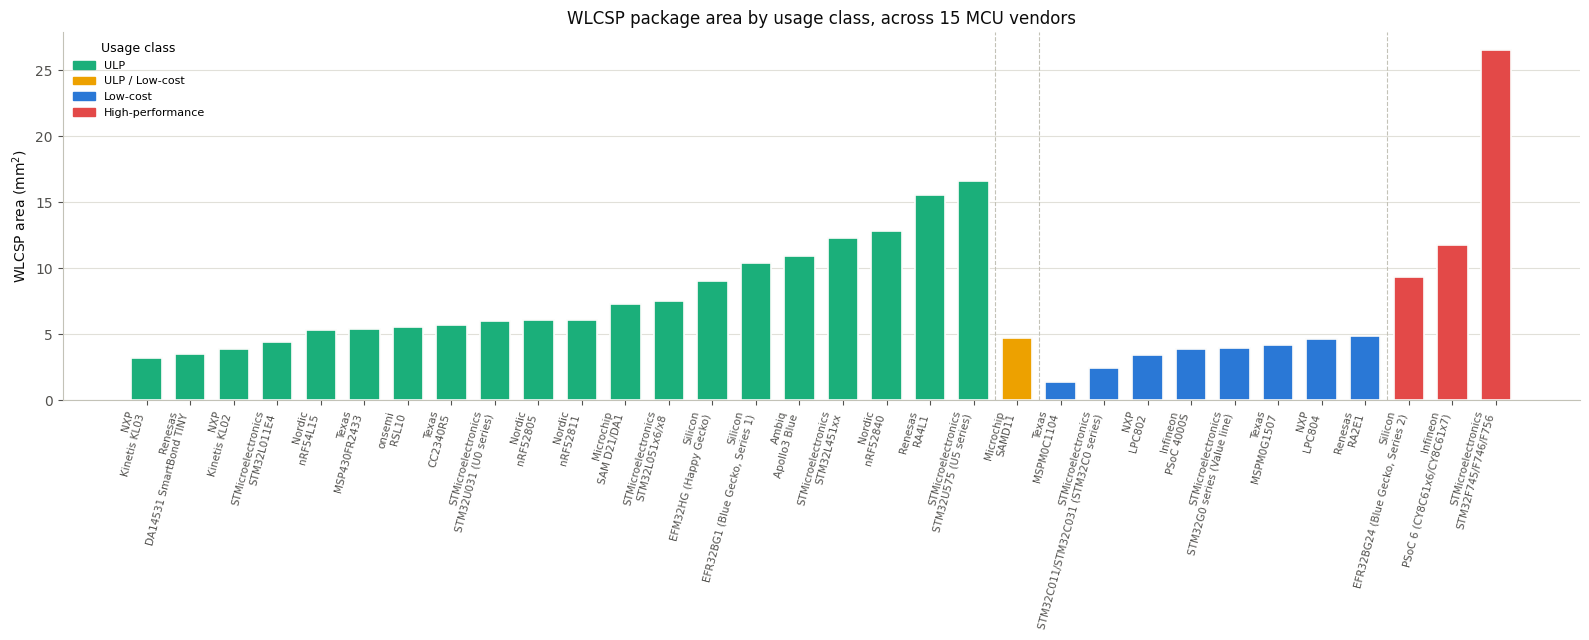

In [4]:
# ------------------------------------------------------------------
# Same data, grouped by usage class (ULP / Low-cost / High-performance)
# instead, for comparison.
# ------------------------------------------------------------------
class_colors = {
    "ULP": "#1baf7a",
    "Low-cost": "#2a78d6",
    "High-performance": "#e34948",
    "ULP / Low-cost": "#eda100",
}
class_order = ["ULP", "ULP / Low-cost", "Low-cost", "High-performance"]

plot_df2 = df.dropna(subset=["wlcsp_area_mm2"]).copy()
plot_df2["class_rank"] = plot_df2["usage_class"].apply(class_order.index)
plot_df2 = plot_df2.sort_values(["class_rank", "wlcsp_area_mm2"])
plot_df2["label"] = plot_df2["manufacturer"].str.split().str[0] + "\n" + plot_df2["mcu_name"]

fig, ax = plt.subplots(figsize=(16, 6.5))
x = range(len(plot_df2))
colors = plot_df2["usage_class"].map(class_colors)
ax.bar(x, plot_df2["wlcsp_area_mm2"], color=colors, width=0.7,
       edgecolor="#fcfcfb", linewidth=1.2)

prev_class = None
for i, c in enumerate(plot_df2["usage_class"]):
    if prev_class is not None and c != prev_class:
        ax.axvline(i - 0.5, color="#c3c2b7", linewidth=0.8, linestyle="--")
    prev_class = c

ax.set_xticks(list(x))
ax.set_xticklabels(plot_df2["label"], rotation=75, ha="right", fontsize=7.5)
ax.set_ylabel("WLCSP area (mm$^2$)", color="#0b0b0b")
ax.set_title("WLCSP package area by usage class, across 15 MCU vendors",
             color="#0b0b0b", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#c3c2b7")
ax.tick_params(colors="#52514e")
ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)

handles = [plt.Rectangle((0, 0), 1, 1, color=class_colors[c]) for c in class_order
           if c in plot_df2["usage_class"].values]
labels = [c for c in class_order if c in plot_df2["usage_class"].values]
ax.legend(handles, labels, title="Usage class", fontsize=8, title_fontsize=9,
          loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig("wlcsp_area_by_usage_class.png", dpi=150, facecolor="#fcfcfb")
plt.show()


Plotting 8 of 38 entries with known WLCSP area.
Skipped (no WLCSP area found): ['STM32L031x4/x6', 'nRF52832', 'SAML10', 'SAM D5x/E5x', 'Apollo4 Blue Plus', 'EFM32WG (Wonder Gecko)']


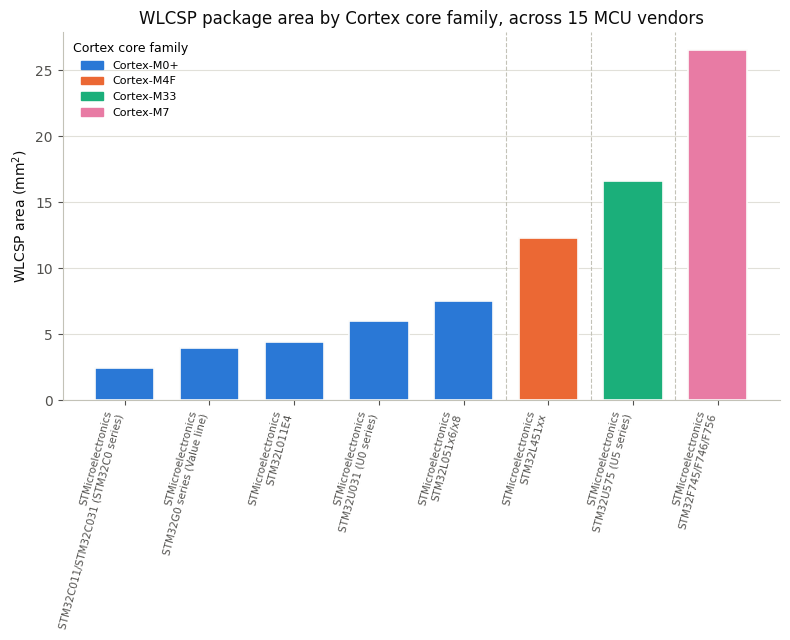

In [5]:
# ------------------------------------------------------------------
# WLCSP area (mm^2), grouped by Cortex core family.
# Entries with no known WLCSP area are skipped (listed below).
# ------------------------------------------------------------------

plot_df = df.dropna(subset=["wlcsp_area_mm2"]).copy()

plot_df = plot_df[plot_df['manufacturer'] == 'STMicroelectronics']

skipped = df.loc[df["wlcsp_area_mm2"].isna(), "mcu_name"].tolist()
print(f"Plotting {len(plot_df)} of {len(df)} entries with known WLCSP area.")
print(f"Skipped (no WLCSP area found): {skipped}")

plot_df["family_rank"] = plot_df["core_family"].apply(FAMILY_ORDER.index)
plot_df = plot_df.sort_values(["family_rank", "wlcsp_area_mm2"])
plot_df["label"] = plot_df["manufacturer"].str.split().str[0] + "\n" + plot_df["mcu_name"]

fig, ax = plt.subplots(figsize=(8, 6.5))
x = range(len(plot_df))
colors = plot_df["core_family"].map(FAMILY_COLORS)

ax.bar(x, plot_df["wlcsp_area_mm2"], color=colors, width=0.7,
       edgecolor="#fcfcfb", linewidth=1.2)

# Thin separators between core-family groups
prev_family = None
for i, fam in enumerate(plot_df["core_family"]):
    if prev_family is not None and fam != prev_family:
        ax.axvline(i - 0.5, color="#c3c2b7", linewidth=0.8, linestyle="--")
    prev_family = fam

ax.set_xticks(list(x))
ax.set_xticklabels(plot_df["label"], rotation=75, ha="right", fontsize=7.5)
ax.set_ylabel("WLCSP area (mm$^2$)", color="#0b0b0b")
ax.set_title("WLCSP package area by Cortex core family, across 15 MCU vendors",
             color="#0b0b0b", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#c3c2b7")
ax.tick_params(colors="#52514e")
ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)

handles = [plt.Rectangle((0, 0), 1, 1, color=FAMILY_COLORS[f]) for f in FAMILY_ORDER
           if f in plot_df["core_family"].values]
labels = [f for f in FAMILY_ORDER if f in plot_df["core_family"].values]
ax.legend(handles, labels, title="Cortex core family", fontsize=8,
          title_fontsize=9, loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig("wlcsp_area_by_core_family.png", dpi=150, facecolor="#fcfcfb")
plt.show()
